## Importing the Required Libraries

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from fredapi import Fred
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm, f, chi2
import seaborn as sns
from tabulate import tabulate
from itertools import zip_longest as lzip
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_white, het_breuschpagan, acorr_breusch_godfrey, acorr_ljungbox, linear_reset, breaks_cusumolsresid
from statsmodels.compat import lzip
import warnings
warnings.filterwarnings("ignore")

## Part a) and b)

a) Download the prices of 2 cryptocurrencies from September 2015 (or the oldest release) to August 2024 (in historical data). Tranform them adequately to have log return x 100 (rt=ln(Pt/Pt−1)x 100). Take the weekly frequency. Download the dataset from the Federal Reserve of St. Louis’ website, https://fred.stlouisfed.org ( SP500 and risk free interest rate Federal Funds Effective Rate) for the same sample period. Take the weekly frequency (ending Sunday).

In [2]:
start_date = pd.to_datetime('2015-08-31')
end_date = pd.to_datetime('2024-08-31')

#using yfinance to import crypto data directly from Yahoo Finance
crypto_currencies = yf.download('BTC-USD ETH-USD', start=start_date, end=end_date, progress = False) 
crypto_currencies = crypto_currencies['Close']

BTC = crypto_currencies['BTC-USD']
ETH = crypto_currencies['ETH-USD']

BTC = BTC.resample('W-SUN').last()
ETH = ETH.resample('W-SUN').last()

Downloading SP500 and Risk-free rate (Federal Funds Effective Rate)

In [3]:
#Utilising the FRED API to retrieve data directly from the Federal Reserve of St. Louis
fred = Fred(api_key='KEY') 

# (wesu) is a paramater which we can use to specify Weekly frequency, ending Sunday
SP500 = pd.DataFrame(fred.get_series('SP500', start_date, end_date, frequency = 'wesu')) 
SP500 = SP500.rename(columns={0:"SP500"})

FFER = pd.DataFrame(fred.get_series('DFF', start_date, end_date, frequency = 'wesu'))
FFER = FFER.rename(columns={0:"FFER"})

In [4]:
BTC = pd.concat([BTC, SP500, FFER], axis = 1)
ETH = pd.concat([ETH, SP500, FFER], axis = 1)

In [5]:
def compute_log_returns(df, crypto_col, sp500_col, ffr_col):
    df_copy = df.copy()
    df_copy[crypto_col] = np.log(df_copy[crypto_col]).diff() * 100 #Transformation to log returns
    df_copy[sp500_col] = np.log(df_copy[sp500_col]).diff() * 100
    result_df = df_copy[[ crypto_col, sp500_col, ffr_col]].dropna()
    return result_df

BTC = compute_log_returns(BTC, 'BTC-USD','SP500','FFER')
ETH = compute_log_returns(ETH, 'ETH-USD','SP500','FFER')

## Part c)

In [6]:
def capm_linear_reg(df, column, constant = True):
    
    df['ex_ret_asset'] = df[column] - df['FFER']
    df['ex_ret_mkt'] = df['SP500'] - df['FFER']
    
    if constant:
        model = smf.ols(formula = 'ex_ret_asset~ex_ret_mkt',data=df).fit()
        df['y_hat'] = model.predict(df[['ex_ret_mkt']])
        df['residuals'] = df['ex_ret_asset'] - df['y_hat']  #residual calculation
        
    else:
        model = smf.ols(formula = 'ex_ret_asset~ex_ret_mkt-1',data=df).fit()
        df['y_hat_no_const'] = model.predict(df[['ex_ret_mkt']])
        df['residuals_no_const'] = df['ex_ret_asset'] - df['y_hat_no_const']  #residual calculation
    
    print('\nOLS Results for', column,':\n', model.summary())
    
    return model

BTC_reg = capm_linear_reg(BTC, 'BTC-USD')
ETH_reg = capm_linear_reg(ETH, 'ETH-USD')


OLS Results for BTC-USD :
                             OLS Regression Results                            
Dep. Variable:           ex_ret_asset   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     44.14
Date:                Sun, 13 Oct 2024   Prob (F-statistic):           8.52e-11
Time:                        14:30:44   Log-Likelihood:                -1728.4
No. Observations:                 469   AIC:                             3461.
Df Residuals:                     467   BIC:                             3469.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1738   

In [7]:
def plot_regression_and_residuals(crypto1, crypto2, robust=False, constant=True, save=True):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Define plot characteristics for each crypto asset
    for idx, df in enumerate([crypto1, crypto2]):
        title_suffix = '(Robust)' if robust else ''
        const_label = '' if constant else ' (No Constant)'
        y_hat_key = 'y_hat_robust' if robust else 'y_hat_no_const' if not constant else 'y_hat'
        residuals_key = 'residuals_robust' if robust else 'residuals_no_const' if not constant else 'residuals'

        # First row - scatter plot of actual vs predicted
        row, col = 0, idx
        axes[row, col].scatter(df['ex_ret_mkt'], df['ex_ret_asset'], color='navy', marker='o', s=10, alpha=0.7, label='Observed Data')
        axes[row, col].plot(df['ex_ret_mkt'], df[y_hat_key], color='darkgray', linewidth=2, label='Regression Line')

        # Titles and labels
        axes[row, col].set_title(f'{df.columns[0]} - Predicted vs Actual {title_suffix} {const_label}', fontsize=14)
        axes[row, col].set_xlabel('Market Excess Return')
        axes[row, col].set_ylabel('Asset Excess Return')
        axes[row, col].legend()

        # Second row - histogram of residuals
        row = 1
        axes[row, col].hist(df[residuals_key], bins=40, color='mediumpurple', edgecolor='black', alpha=0.5, density=True, label='Residuals')

        # Overlay normal distribution curve
        mean_resid, std_resid = df[residuals_key].mean(), df[residuals_key].std()
        x_values = np.linspace(df[residuals_key].min(), df[residuals_key].max(), 100)
        normal_pdf = stats.norm.pdf(x_values, mean_resid, std_resid)
        axes[row, col].plot(x_values, normal_pdf, color='thistle', linewidth=2.5, linestyle='-', alpha=1, label='Normal Distribution')
        axes[row, col].fill_between(x_values, 0, normal_pdf, color='thistle', alpha=0.5)

        # Titles and labels for residuals plot
        axes[row, col].set_title(f'Residuals Distribution - {df.columns[0]}', fontsize=14)
        axes[row, col].set_xlabel('Residuals')
        axes[row, col].set_ylabel('Density')
        axes[row, col].legend()

    # Adjust layout and optionally save the plot
    plt.tight_layout()
    if save:
        file_suffix = 'robust' if robust else 'nonrobust'
        const_suffix = '' if constant else '_noConstant'
        plt.savefig(f"/Users/jamesmurphy/FIN30200/regression_residuals_{file_suffix}{const_suffix}.jpeg", dpi=300, bbox_inches='tight')

    # Display the plot
    plt.show()

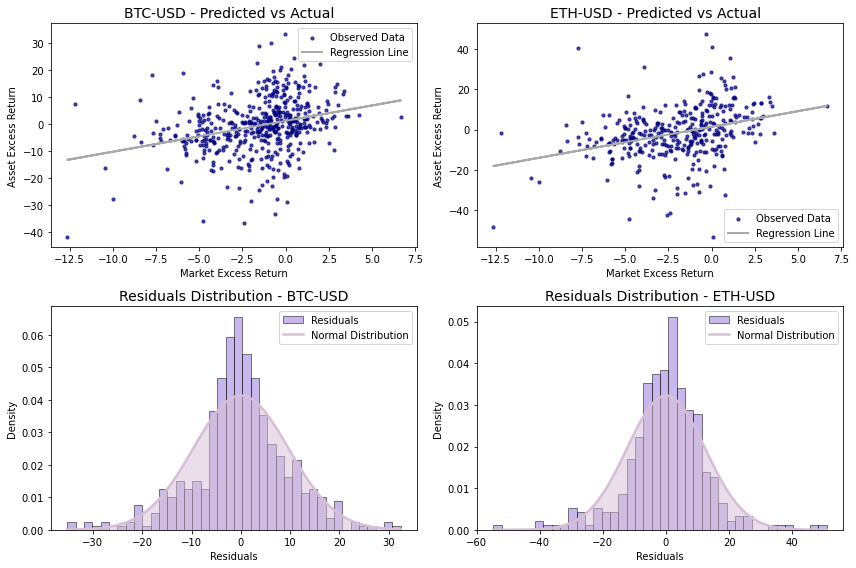

In [8]:
plot_regression_and_residuals(BTC, ETH, robust=False, constant=True, save=True)

#### Tests for Non-normality

In [9]:
def jarque_bera_test(reg, crypto_name):
    crypto = crypto_name[:3]
    residuals = reg.resid
    jb_stat, jb_pvalue = stats.jarque_bera(residuals)
    
    print("\n--- Jarque-Bera Test ({}) ---".format(crypto))
    print(f"Test Statistic: {round(jb_stat, 3)}")
    print(f"p-value: {round(jb_pvalue, 3)}")
    print("------------------------------")

jarque_bera_test(BTC_reg, 'BTC')
jarque_bera_test(ETH_reg, 'ETH')


--- Jarque-Bera Test (BTC) ---
Test Statistic: 40.723
p-value: 0.0
------------------------------

--- Jarque-Bera Test (ETH) ---
Test Statistic: 128.966
p-value: 0.0
------------------------------


#### Testing for Serial Correlation/ Autocorrelation

In [10]:
def plot_autocorrelation(reg, crypto_name, lags=50):

    # Extract the residuals from the regression result
    residuals = reg.resid 
    fig, ax = plt.subplots(figsize=(16, 8))  
    sm.graphics.tsa.plot_acf(residuals, lags=lags, alpha=0.05, ax=ax)  # 95% confidence interval (5% significance level)
    
    ax.set_title(f"Autocorrelation Function (ACF) of Residuals - {crypto_name}", fontsize=20)
    ax.set_xlabel("Lags", fontsize=16)
    ax.set_ylabel("Autocorrelation", fontsize=16)
    
    # Add grid lines for better readability
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Show plot
    plt.tight_layout() 
    plt.show()

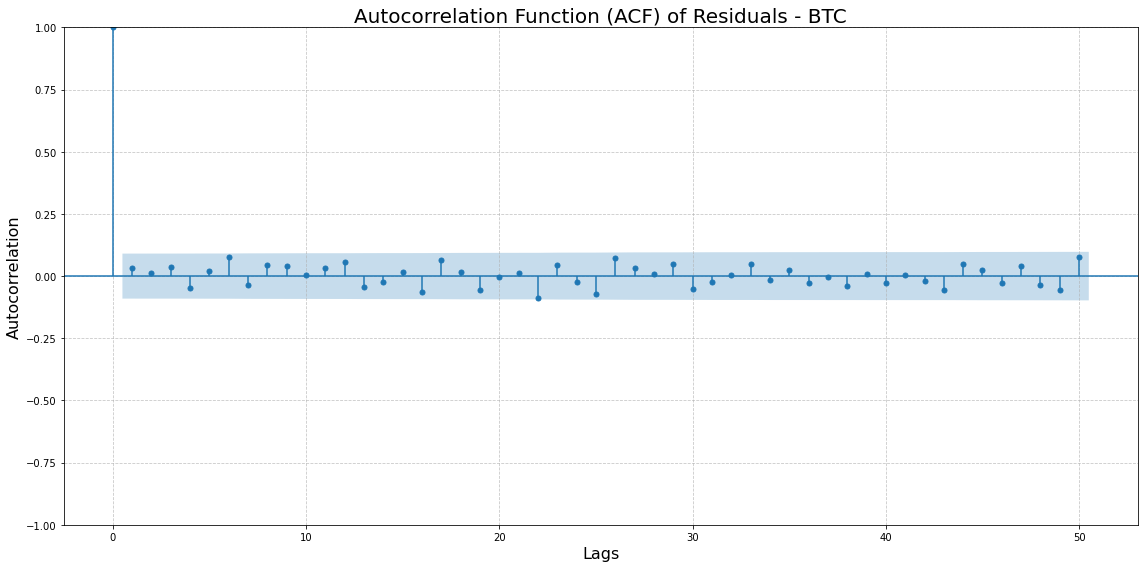

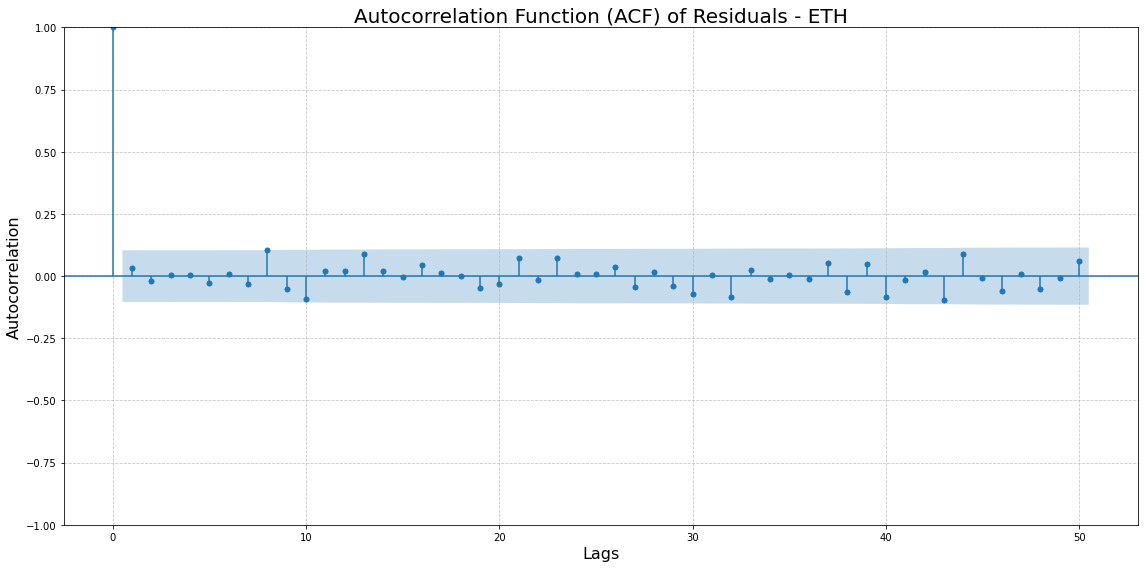

In [11]:
plot_autocorrelation(BTC_reg, 'BTC')
plot_autocorrelation(ETH_reg, 'ETH')

In [12]:
def q_stats(reg, crypto_name, nlags=50):
    
    series = reg.resid
    # Run the autocorrelation function (ACF) with qstat=True for Ljung-Box Q-Statistic
    acf_results = sm.tsa.acf(series, qstat=True, nlags=nlags, alpha=0.05)
    
    # Create a dictionary to hold Q-Stats and p-values
    q_stats = {'Q-Stats': acf_results[2], 'p-values': acf_results[3]}
    
    # Convert the dictionary to a DataFrame
    df_q_stats = pd.DataFrame(q_stats)
    
    # Add the 'Lag' column
    df_q_stats['Lag'] = range(1, nlags + 1)
    
    # Reorder the columns to show 'Lag' first
    df_q_stats = df_q_stats[['Lag', 'Q-Stats', 'p-values']]
    
    # Return the DataFrame
    return df_q_stats

q_stats(BTC_reg, 'BTC', nlags = 50)

,Lag,Q-Stats,p-values
0,1,0.477445,0.489582
1,2,0.538844,0.763821
2,3,1.130827,0.769638
3,4,2.166236,0.705215
4,5,2.370739,0.795824
5,6,5.103652,0.530589
6,7,5.775255,0.566223
7,8,6.702529,0.569041
8,9,7.461171,0.589220
9,10,7.464659,0.680970


#### Breusch-Godfrey Test

In [13]:
def run_breusch_godfrey_test(reg, crypto_name, nlags=10):
    
    bg_test = acorr_breusch_godfrey(reg, nlags=nlags)
    
    lm_stat = bg_test[0]  # LM Statistic
    p_value = bg_test[1]  # p-value
    print(f"\n--- Breusch-Godfrey Test for {crypto_name} ---")
    print(f"Lagrange Multiplier (LM) Statistic: {lm_stat}")
    print(f"p-value: {p_value}")
    
    # Return the results
    return lm_stat, p_value

bg_test_btc = run_breusch_godfrey_test(BTC_reg, 'BTH')
bg_test_eth = run_breusch_godfrey_test(ETH_reg, 'ETH')


--- Breusch-Godfrey Test for BTH ---
Lagrange Multiplier (LM) Statistic: 7.238448548035821
p-value: 0.7027584798664216

--- Breusch-Godfrey Test for ETH ---
Lagrange Multiplier (LM) Statistic: 9.500509803104517
p-value: 0.4853507812328879


#### Durbin-Watson Test

In [14]:
def durbin_watson(reg):
    
    durbin_watson_test = sms.durbin_watson(reg.resid)
    print('Durbin-Watson Statistic:', durbin_watson_test)

In [15]:
durbin_watson(BTC_reg)

Durbin-Watson Statistic: 1.933696825857483


In [16]:
durbin_watson(ETH_reg)

Durbin-Watson Statistic: 1.9296058612554603


#### Checking for Heteroskedasticity

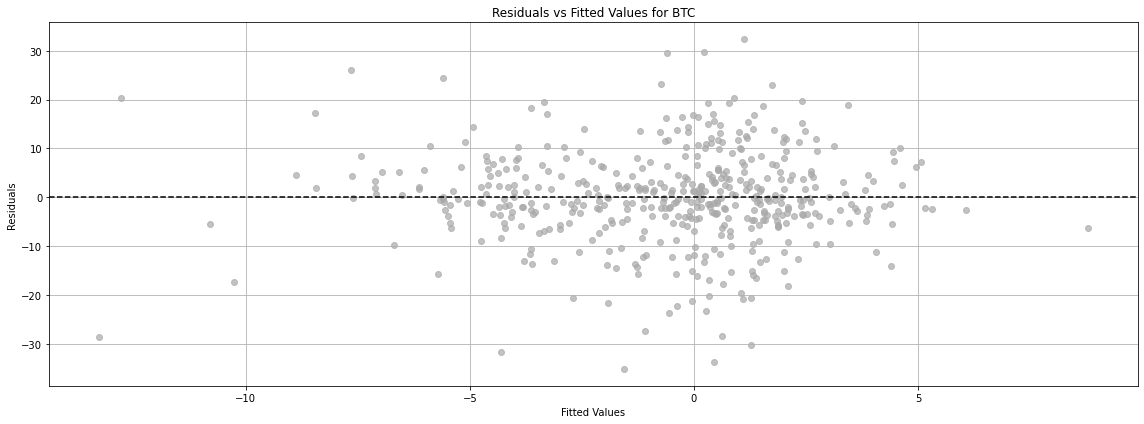

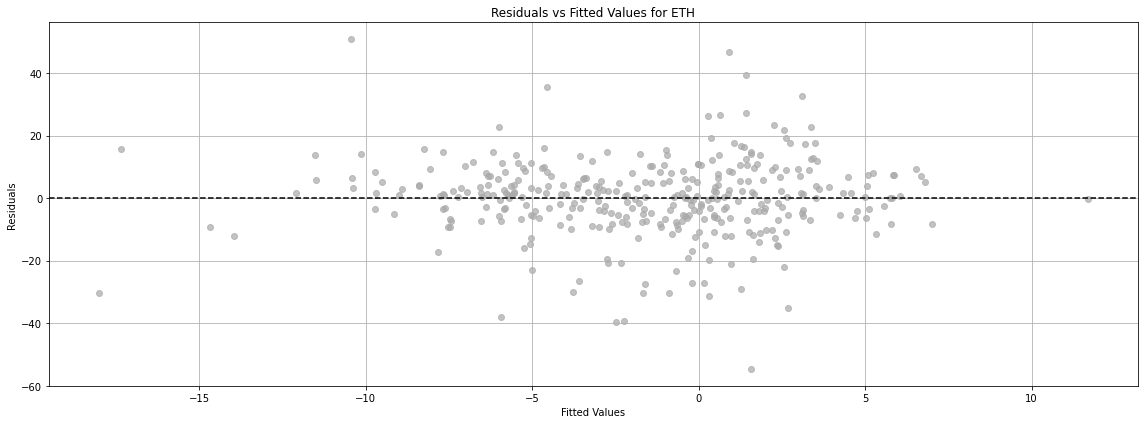

In [17]:
def plot_residuals_vs_fitted(reg, crypto_name):
    
    residuals = reg.resid
    fitted = reg.fittedvalues
    
    plt.figure(figsize=(16, 6))
    plt.scatter(fitted, residuals, color = 'darkgrey', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.title(f'Residuals vs Fitted Values for {crypto_name}')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.grid(True)
    plt.tight_layout() 
    plt.show()

plot_residuals_vs_fitted(BTC_reg, 'BTC')
plot_residuals_vs_fitted(ETH_reg, 'ETH')

#### Breusch-Pagan Test

In [18]:
def breusch_pagan_test(reg):
    
    breuschpagan_name = ['Breusch-Pagan Lagrange Multiplier Statistic', 'p-value', 'f-value', 'f p-value']
    breuschpagan_test = sms.het_breuschpagan(reg.resid, reg.model.exog)
    print(tabulate(lzip(breuschpagan_name, breuschpagan_test), headers=['Test', 'Value'], tablefmt='pretty'))

breusch_pagan_test(BTC_reg)
breusch_pagan_test(ETH_reg)

+---------------------------------------------+---------------------+
|                    Test                     |        Value        |
+---------------------------------------------+---------------------+
| Breusch-Pagan Lagrange Multiplier Statistic |  1.059525205288807  |
|                   p-value                   | 0.30332349958403415 |
|                   f-value                   | 1.0573957533529281  |
|                  f p-value                  | 0.30434220062716555 |
+---------------------------------------------+---------------------+
+---------------------------------------------+----------------------+
|                    Test                     |        Value         |
+---------------------------------------------+----------------------+
| Breusch-Pagan Lagrange Multiplier Statistic | 0.002152650256014854 |
|                   p-value                   |   0.96299409689102   |
|                   f-value                   | 0.002140535628732528 |
|             

#### White Test

In [19]:
def white_test(reg):

    white_test_name = ['White Test Lagrange Multiplier Statistic', 'p-value', 'f-value', 'f p-value']
    white_test_results = sms.het_white(reg.resid, reg.model.exog)
    print(tabulate(lzip(white_test_name, white_test_results), headers=['Test', 'Value'], tablefmt='pretty'))

white_test(BTC_reg)
white_test(ETH_reg)

+------------------------------------------+---------------------+
|                   Test                   |        Value        |
+------------------------------------------+---------------------+
| White Test Lagrange Multiplier Statistic |  2.81691337334501   |
|                 p-value                  | 0.24452036363797014 |
|                 f-value                  | 1.4079035357947802  |
|                f p-value                 | 0.24569435819549704 |
+------------------------------------------+---------------------+
+------------------------------------------+---------------------+
|                   Test                   |        Value        |
+------------------------------------------+---------------------+
| White Test Lagrange Multiplier Statistic | 0.30646724708148276 |
|                 p-value                  | 0.8579292659238876  |
|                 f-value                  | 0.15206997169557726 |
|                f p-value                 | 0.858984576184985

#### Goldfeld - Quandt Test

In [20]:
def goldfeld_quandt_test(model, crypto_name):
    
    goldfeldquandt_name = ['F-statistic', 'p-value']
    goldfeldquandt_test = sms.het_goldfeldquandt(model.resid, model.model.exog, split=0.5)
    test_result = lzip(goldfeldquandt_name, goldfeldquandt_test)
    print(f"\n\nResults for {crypto_name}:")
    print(f"F-statistic: {test_result[0][1]}")
    print(f"p-value: {test_result[1][1]}")

goldfeld_quandt_test(BTC_reg, "BTC-USD")
goldfeld_quandt_test(ETH_reg, "ETH-USD")



Results for BTC-USD:
F-statistic: 0.6074233920244703
p-value: 0.9999204937343995


Results for ETH-USD:
F-statistic: 0.490744882159583
p-value: 0.9999984064024396


## Part d)

In [21]:
def capm_linear_reg_robust_se(df, column, constant = True):
    
    df['ex_ret_asset'] = df[column] - df['FFER']
    df['ex_ret_mkt'] = df['SP500'] - df['FFER']
    
    if constant:
        model = smf.ols(formula = 'ex_ret_asset~ex_ret_mkt',data=df).fit(cov_type='HAC', cov_kwds={'maxlags':12, 'use_correction':True})
        df['y_hat_robust'] = model.predict(df[['ex_ret_mkt']])
        df['residuals_robust'] = df['ex_ret_asset'] - df['y_hat_robust']  #residual calculation
        
    else:
        model = smf.ols(formula = 'ex_ret_asset~ex_ret_mkt-1',data=df).fit(cov_type='HAC', cov_kwds={'maxlags':12, 'use_correction':True})
        df['y_hat_robust_no_const'] = model.predict(df[['ex_ret_mkt']])
        df['residuals_robust_no_const'] = df['ex_ret_asset'] - df['y_hat_robust_no_const']  #residual calculation
    
    print('\nOLS Results for', column,':\n', model.summary())
    
    return model

BTC_reg_robust = capm_linear_reg_robust_se(BTC, 'BTC-USD')
ETH_reg_robust = capm_linear_reg_robust_se(ETH, 'ETH-USD')


OLS Results for BTC-USD :
                             OLS Regression Results                            
Dep. Variable:           ex_ret_asset   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     55.77
Date:                Sun, 13 Oct 2024   Prob (F-statistic):           4.04e-13
Time:                        14:30:47   Log-Likelihood:                -1728.4
No. Observations:                 469   AIC:                             3461.
Df Residuals:                     467   BIC:                             3469.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1738   

Comparing Standard Errors

In [22]:
def check_standard_errors(df, crypto_name):
    # Non-robust model
    model = smf.ols(formula='ex_ret_asset ~ ex_ret_mkt', data=df).fit()

    # Robust model
    model_robust = smf.ols(formula='ex_ret_asset ~ ex_ret_mkt', data=df).fit(cov_type='HAC', cov_kwds={'maxlags': 12})

    # Compare the standard errors
    print("\n\nNon-Robust Standard Errors ({}):".format(crypto_name))
    print(model.bse)

    print("\nRobust Standard Errors ({}):".format(crypto_name))
    print(model_robust.bse)

In [23]:
check_standard_errors(BTC, 'BTC')
check_standard_errors(ETH, 'ETH')



Non-Robust Standard Errors (BTC):
Intercept     0.522019
ex_ret_mkt    0.172128
dtype: float64

Robust Standard Errors (BTC):
Intercept     0.571124
ex_ret_mkt    0.152817
dtype: float64


Non-Robust Standard Errors (ETH):
Intercept     0.805520
ex_ret_mkt    0.236246
dtype: float64

Robust Standard Errors (ETH):
Intercept     0.861393
ex_ret_mkt    0.240704
dtype: float64


## Part e)

In [24]:
hypotheses_test = "ex_ret_mkt = 1"

regression_models = {'BTC': BTC_reg_robust, 'ETH': ETH_reg_robust}

for crypto_name, reg in regression_models.items():
    t_stat = reg.t_test(hypotheses_test)
    print(f"\nHypothesis Test for {crypto_name}:")
    print(t_stat)


Hypothesis Test for BTC:
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.1436      0.153      0.938      0.348       0.843       1.444

Hypothesis Test for ETH:
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.5398      0.241      2.236      0.025       1.067       2.013


In [25]:
regression_models = {'BTC': BTC_reg_robust, 'ETH': ETH_reg_robust}

for crypto_name, reg in regression_models.items():
    conf_interval = reg.conf_int(alpha=0.05)  # 95% confidence interval
    print(f"\n95% Confidence Interval for {crypto_name}:")
    print(conf_interval)


95% Confidence Interval for BTC:
                   0         1
Intercept   0.052026  2.295578
ex_ret_mkt  0.843473  1.443787

95% Confidence Interval for ETH:
                   0         1
Intercept  -0.254011  3.132140
ex_ret_mkt  1.066742  2.012953


## Part f)

Identifying a suitable timepoint for splitting the data in order to effectively implement the Chow Test to look for parameter instabilities

Observation with highest leverage for BTC-USD: 2020-03-15 00:00:00


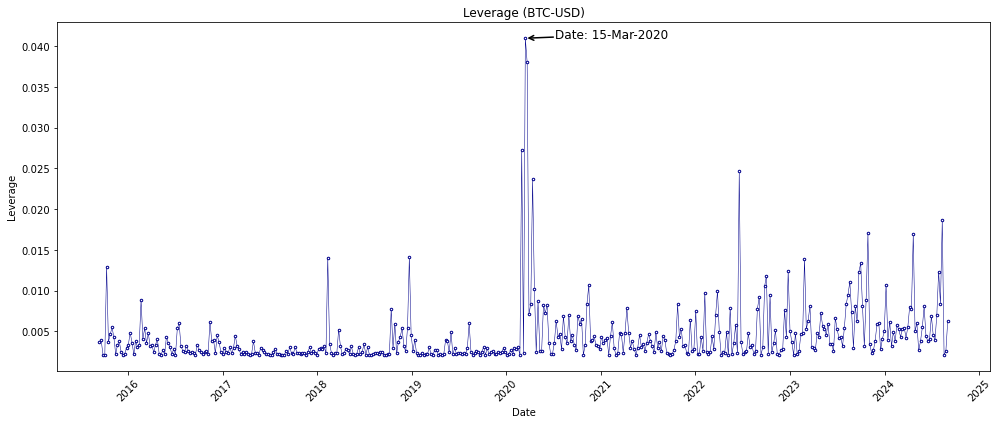

Observation with highest leverage for ETH-USD: 2020-03-15 00:00:00


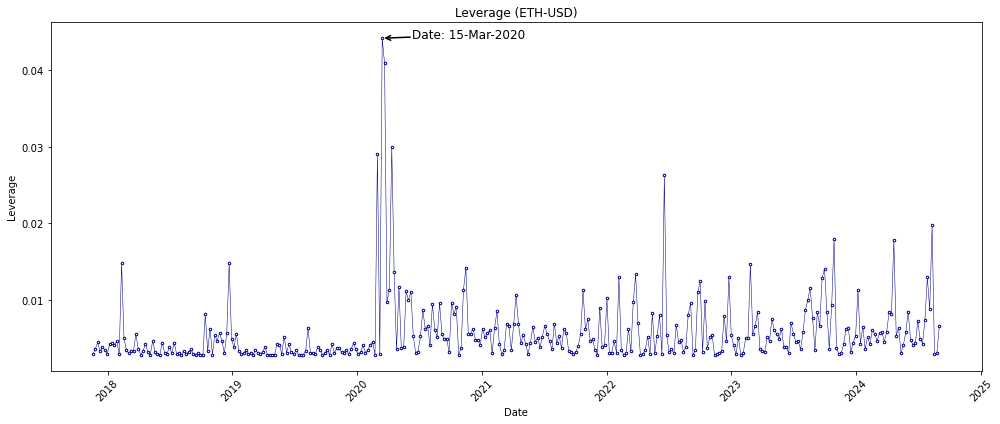

In [26]:
def leverage_influence(model, crypto_df):

    # Calculate Leverage (hat values)
    infl = model.get_influence()
    leverage = infl.hat_matrix_diag
    leverage_df = pd.DataFrame({'Date': crypto_df.index, "Leverage": leverage})
    idx_max = leverage_df["Leverage"].idxmax()
    max_leverage = leverage_df["Leverage"].max()
    date_max = crypto_df.index[idx_max]
    
    plt.figure(figsize=(14, 6))
    plt.plot(leverage_df['Date'], leverage_df["Leverage"], markeredgecolor='darkblue', marker='.', markersize=5,
             markerfacecolor='white', linestyle='-', color='darkblue', linewidth=0.5)
    
    plt.annotate(f"Date: {date_max.strftime('%d-%b-%Y')}", (date_max, max_leverage),
                 xytext=(30, 0), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', lw=1.5, color='black', shrinkA=0),
                 fontsize=12, color='black')  
    plt.title(f"Leverage ({crypto_df.columns[0]})")
    plt.xlabel('Date')
    plt.ylabel("Leverage")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"leverageInfluence_{crypto_df.columns[0]}.jpeg", dpi=300, bbox_inches='tight')
    print(f"Observation with highest leverage for {crypto_df.columns[0]}: {date_max}")
    plt.show()

leverage_influence(BTC_reg, BTC)
leverage_influence(ETH_reg, ETH)

Identifying the worst weekly performance of BTC and ETH

In [27]:
def worst_performance(df,asset):
    print("\n\n{} Worst Recorded Performance:".format(asset))
    print("Timestamp: {}".format(df[asset].idxmin()))
    print("Return: {}".format(df[asset].min()))

worst_performance(BTC,'BTC-USD')
worst_performance(ETH,'ETH-USD')
worst_performance(BTC,'SP500')



BTC-USD Worst Recorded Performance:
Timestamp: 2020-03-15 00:00:00
Return: -40.78907804416563


ETH-USD Worst Recorded Performance:
Timestamp: 2021-05-23 00:00:00
Return: -53.09684855669783


SP500 Worst Recorded Performance:
Timestamp: 2020-03-22 00:00:00
Return: -12.004422381000612


Identifying the five worst weekly performances of ETH

In [28]:
lowest_values = ETH['ETH-USD'].nsmallest(5)
print(lowest_values.index, lowest_values.values)

DatetimeIndex(['2021-05-23', '2020-03-15', '2018-11-25', '2018-09-09',
               '2018-02-04'],
              dtype='datetime64[ns]', freq=None) [-53.09684856 -47.17300413 -41.90662295 -40.2023037  -40.06509107]


In [29]:
lowest_values = BTC['SP500'].nsmallest(5)
print(lowest_values.index, lowest_values.values)

DatetimeIndex(['2020-03-22', '2020-03-15', '2020-03-01', '2022-06-19',
               '2018-02-11'],
              dtype='datetime64[ns]', freq=None) [-12.00442238 -11.53529337  -8.88269614  -8.73767975  -6.28250294]


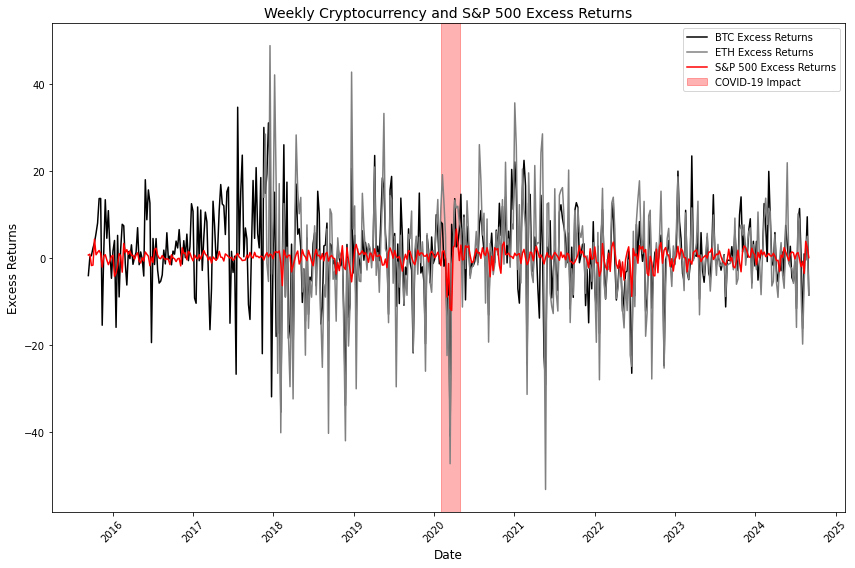

In [30]:
#Date ranges for the COVID-19 pandemic period
highlight_start = '2020-02-01'
highlight_end = '2020-05-01'

plt.figure(figsize=(12, 8))

# Plot BTC weekly excess returns
plt.plot(BTC.index, BTC['BTC-USD'], label='BTC Excess Returns', color='black', linewidth=1.5)

# Plot ETH weekly excess returns
plt.plot(ETH.index, ETH['ETH-USD'], label='ETH Excess Returns', color='grey', linewidth=1.5)

# Plot SP500 weekly excess returns
plt.plot(BTC.index, BTC['SP500'], label='S&P 500 Excess Returns', color='red', linewidth=1.5)

# Highlight a period of intense volatility (e.g., during the COVID-19 pandemic)
plt.axvspan(highlight_start, highlight_end, color='red', alpha=0.3, label='COVID-19 Impact')
plt.title('Weekly Cryptocurrency and S&P 500 Excess Returns', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Excess Returns', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Date obtained by using Leverage (Hat Values)
# Sunday of the week that the pandemic was declared
split_date = '2020-03-15' 

BTC_sample1 = BTC[BTC.index < split_date]
BTC_sample2 = BTC[BTC.index >= split_date]

ETH_sample1 = ETH[ETH.index <= split_date]
ETH_sample2 = ETH[ETH.index > split_date]

# Running the regression for BTC (pre-COVID and post-COVID)
BTC_reg_sample1 = capm_linear_reg(BTC_sample1, 'BTC-USD')
BTC_reg_sample2 = capm_linear_reg(BTC_sample2, 'BTC-USD')

# Running the regression for ETH (pre-COVID and post-COVID)
ETH_reg_sample1 = capm_linear_reg(ETH_sample1, 'ETH-USD')
ETH_reg_sample2 = capm_linear_reg(ETH_sample2, 'ETH-USD')


OLS Results for BTC-USD :
                             OLS Regression Results                            
Dep. Variable:           ex_ret_asset   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     7.003
Date:                Sun, 13 Oct 2024   Prob (F-statistic):            0.00869
Time:                        14:30:49   Log-Likelihood:                -891.28
No. Observations:                 235   AIC:                             1787.
Df Residuals:                     233   BIC:                             1793.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4094   

#### Chow Test

In [32]:
def chow_test(fitted_full_model, fitted_first_half_model, fitted_second_half_model, crypto_name):
    
    # Get the residual sum of squares (RSS) for each model
    RSS_full = sum(fitted_full_model.resid ** 2)  # Pooled model RSS
    RSS_first_half = sum(fitted_first_half_model.resid ** 2)
    RSS_second_half = sum(fitted_second_half_model.resid ** 2)
    
    # Number of parameters in the model (k)
    k = len(fitted_full_model.params)
    
    # Number of observations in each subset
    n_first_half = len(fitted_first_half_model.resid)
    n_second_half = len(fitted_second_half_model.resid)
    n_full = len(fitted_full_model.resid)
    
    # Calculate the Chow test F-statistic
    numerator = (RSS_full - (RSS_first_half + RSS_second_half)) / k
    denominator = (RSS_first_half + RSS_second_half) / (n_first_half + n_second_half - 2 * k)
    F_stat = numerator / denominator
    
    # Calculate the p-value using the F-distribution
    df1 = k  # degrees of freedom for numerator
    df2 = (n_first_half + n_second_half - 2 * k)  # degrees of freedom for denominator
    p_value = 1 - stats.f.cdf(F_stat, df1, df2)  # Right-tail p-value for F-distribution
    
    # Print the F-statistic and p-value
    print("\n\nChow Test Results for {}".format(crypto_name))
    print(f"F-statistic: {F_stat}")
    print(f"p-value: {p_value}")
    
    # Conclusion based on p-value
    if p_value < 0.05:
        print(f"There is evidence of a structural break in the {crypto_name} data (p-value < 0.05).")
    else:
        print(f"There is no significant structural break detected in the {crypto_name} data (p-value >= 0.05).")
        
chow_test(BTC_reg, BTC_reg_sample1, BTC_reg_sample2, "BTC")
chow_test(ETH_reg, ETH_reg_sample1, ETH_reg_sample2, "ETH")



Chow Test Results for BTC
F-statistic: 0.21947418158223111
p-value: 0.8030240159824168
There is no significant structural break detected in the BTC data (p-value >= 0.05).


Chow Test Results for ETH
F-statistic: 1.2512944490211657
p-value: 0.28740734523969524
There is no significant structural break detected in the ETH data (p-value >= 0.05).


#### Quandt-Andrews Test

In [33]:
def quandt_andrews_test(model, crypto_name):

    # Perform the Quandt-Andrews test using residuals
    qa_test = sm.stats.diagnostic.breaks_cusumolsresid(model.resid)

    # Display the results
    print(f"\nQuandt-Andrews Test Results for {crypto_name}:")
    print(f"Test statistic: {qa_test[0]}")
    print(f"p-value: {qa_test[1]}")
    if qa_test[1] < 0.05:
        print(f"There is a significant structural break in the {crypto_name} data (p-value < 0.05).")
    else:
        print(f"There is no significant structural break in the {crypto_name} data (p-value >= 0.05).")

In [34]:
quandt_andrews_test(BTC_reg, 'BTC-USD')
quandt_andrews_test(ETH_reg, 'ETH-USD')


Quandt-Andrews Test Results for BTC-USD:
Test statistic: 1.3050649077564134
p-value: 0.06631904874316534
There is no significant structural break in the BTC-USD data (p-value >= 0.05).

Quandt-Andrews Test Results for ETH-USD:
Test statistic: 0.6863182548875724
p-value: 0.7338745057062599
There is no significant structural break in the ETH-USD data (p-value >= 0.05).


## Part g)

Repeat point c) without the constant.

In [37]:
BTC_reg_no_constant = capm_linear_reg(BTC, 'BTC-USD', constant = False)
ETH_reg_no_constant = capm_linear_reg(ETH, 'ETH-USD', constant = False)


OLS Results for BTC-USD :
                                  OLS Regression Results                                
Dep. Variable:           ex_ret_asset   R-squared (uncentered):                   0.080
Model:                            OLS   Adj. R-squared (uncentered):              0.078
Method:                 Least Squares   F-statistic:                              40.70
Date:                Sun, 13 Oct 2024   Prob (F-statistic):                    4.27e-10
Time:                        14:30:51   Log-Likelihood:                         -1730.9
No. Observations:                 469   AIC:                                      3464.
Df Residuals:                     468   BIC:                                      3468.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------

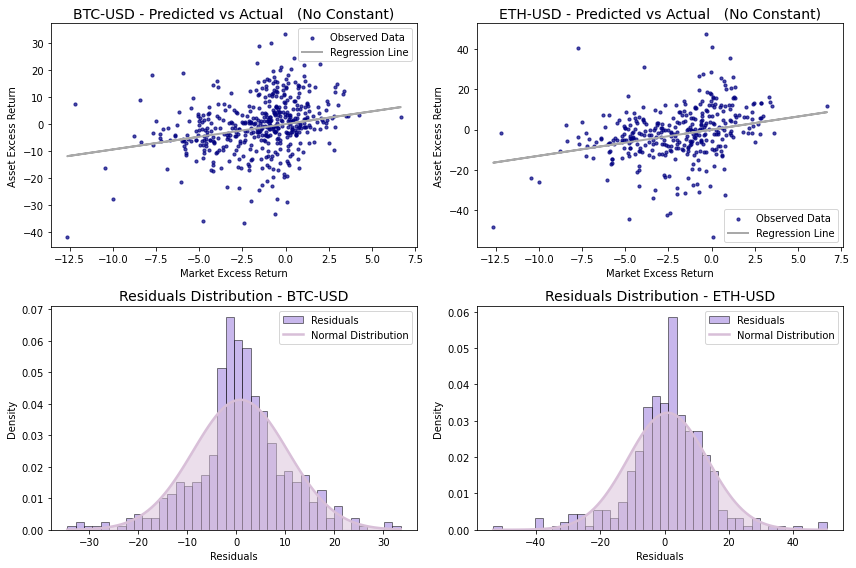

In [38]:
plot_regression_and_residuals(BTC, ETH, robust=False, constant=False, save=True)

#### Likelihood Ratio Test

In [39]:
def log_likelihood_test(model_with_const, model_without_const, crypto_name):

    # Perform the Likelihood Ratio Test
    lr_test = model_with_const.compare_lr_test(model_without_const)
    
    # Extract LR statistic and p-value
    lr_stat = lr_test[0]
    p_value = lr_test[1]

    # Print the results
    print(f"\nLikelihood Ratio Test for {crypto_name}:\n")
    print(f"LR Test Statistic: {lr_stat}")
    print(f"p-value: {p_value}")

    if p_value < 0.05:
        print(f"\nThe model with a constant provides a better fit for {crypto_name} (p-value < 0.05). "
              "You should include the constant in the model.\n")
    else:
        print(f"\nThe model without a constant is sufficient for {crypto_name} (p-value >= 0.05). "
              "Including the constant does not significantly improve the model.\n")

In [40]:
log_likelihood_test(BTC_reg, BTC_reg_no_constant, 'BTC')
log_likelihood_test(ETH_reg, ETH_reg_no_constant, 'ETH')


Likelihood Ratio Test for BTC:

LR Test Statistic: 5.05046692053611
p-value: 0.02461930314567836

The model with a constant provides a better fit for BTC (p-value < 0.05). You should include the constant in the model.


Likelihood Ratio Test for ETH:

LR Test Statistic: 3.1952536705466628
p-value: 0.0738523118277696

The model without a constant is sufficient for ETH (p-value >= 0.05). Including the constant does not significantly improve the model.



#### RESET Test

In [41]:
reset_test_with_const = linear_reset(BTC_reg, power=2)
print(f"RESET Test with constant p-value: {reset_test_with_const.pvalue}")

# Perform the RESET test on the model without a constant
reset_test_without_const = linear_reset(BTC_reg_no_constant, power=2)
print(f"RESET Test without constant p-value: {reset_test_without_const.pvalue}")

RESET Test with constant p-value: 0.8397613063157051
RESET Test without constant p-value: 0.6865872860234747


#### AIC vs BIC

In [42]:
def aic_bic(model_with_constant, model_no_constant, crypto_name):
    
    aic_with_const = model_with_constant.aic
    bic_with_const = model_with_constant.bic

    aic_without_const = model_no_constant.aic
    bic_without_const = model_no_constant.bic

    print("\n\nResults for {}:".format(crypto_name))
    print(f"AIC with constant: {aic_with_const}, without constant: {aic_without_const}")
    print(f"BIC with constant: {bic_with_const}, without constant: {bic_without_const}")

In [43]:
aic_bic(BTC_reg, BTC_reg_no_constant, 'BTC')
aic_bic(ETH_reg, ETH_reg_no_constant, 'ETH')



Results for BTC:
AIC with constant: 3460.8119520750915, without constant: 3463.8624189956276
BIC with constant: 3469.113157611984, without constant: 3468.013021764074


Results for ETH:
AIC with constant: 2796.0062162295444, without constant: 2797.201469900091
BIC with constant: 2803.750451808495, without constant: 2801.0735876895665


#### Residuals

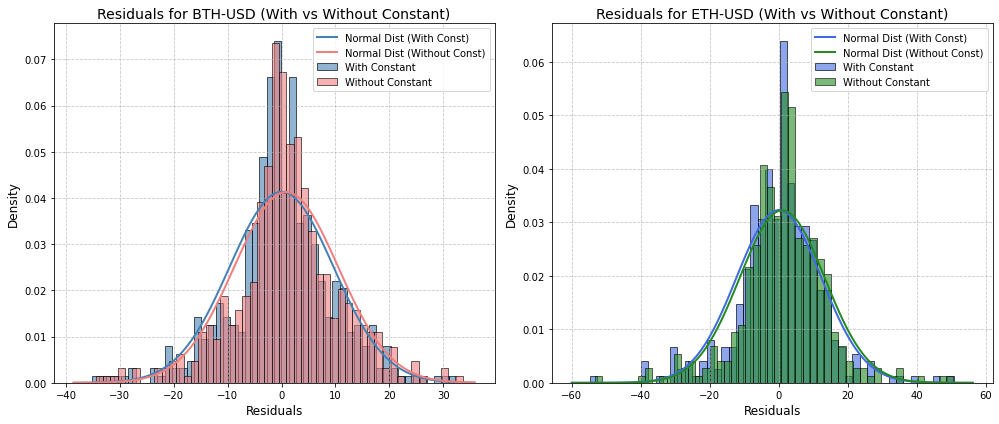

In [44]:
def plot_residuals(df, residuals_with_const, residuals_without_const, crypto_name, ax, color1, color2):

    # Residuals with constant
    sns.histplot(df[residuals_with_const], bins=50, kde=False, color=color1, stat='density', edgecolor='black', alpha=0.6, label='With Constant', ax=ax)
    mu_with, std_with = stats.norm.fit(df[residuals_with_const])
    x = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
    p_with = stats.norm.pdf(x, mu_with, std_with)
    ax.plot(x, p_with, color1, linewidth=2, label='Normal Dist (With Const)')

    # Residuals without constant
    sns.histplot(df[residuals_without_const], bins=50, kde=False, color=color2, stat='density', edgecolor='black', alpha=0.6, label='Without Constant', ax=ax)
    mu_without, std_without = stats.norm.fit(df[residuals_without_const])
    p_without = stats.norm.pdf(x, mu_without, std_without)
    ax.plot(x, p_without, color2, linewidth=2, label='Normal Dist (Without Const)')

    ax.set_title(f"Residuals for {crypto_name} (With vs Without Constant)", fontsize=14)
    ax.set_xlabel("Residuals", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

def plot_residuals_comparison(df1, residuals_with_const1, residuals_without_const1, crypto_name1,
                              df2, residuals_with_const2, residuals_without_const2, crypto_name2):

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
    plot_residuals(df1, residuals_with_const1, residuals_without_const1, crypto_name1, axes[0], 'steelblue', 'lightcoral')
    plot_residuals(df2, residuals_with_const2, residuals_without_const2, crypto_name2, axes[1], 'royalblue', 'forestgreen')
    plt.tight_layout()
    plt.show()

plot_residuals_comparison(BTC, 'residuals', 'residuals_no_const', 'BTH-USD', 
                          ETH, 'residuals', 'residuals_no_const', 'ETH-USD')

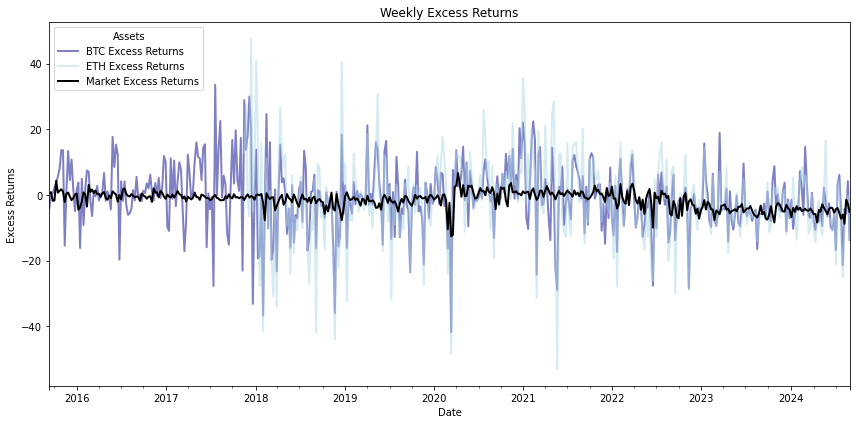

In [45]:
plt.figure(figsize=(12, 6))

plt.title("Weekly Excess Returns",)

BTC['ex_ret_asset'].plot(label='BTC Excess Returns', color = 'darkblue', alpha=0.5, linestyle='-', linewidth=2)

ETH['ex_ret_asset'].plot(label='ETH Excess Returns', color = 'lightblue', alpha=0.5, linestyle='-', linewidth=2)

BTC['ex_ret_mkt'].plot(label='Market Excess Returns', color='black', linestyle='-', linewidth=2)

plt.legend(loc='upper left', frameon=True, title='Assets')
plt.xlabel("Date")
plt.ylabel("Excess Returns")


plt.tight_layout()
plt.savefig(r"WeeklyExcessReturns.jpeg", dpi=300, bbox_inches='tight')

plt.show()